In [2]:
#tool setup 
import os, itertools
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
import statsmodels.formula.api as smf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error as mse

path = '/Users/elliehe/Desktop/DSCI 552/HW2/Folds5x2_pp.xlsx'
df = pd.read_excel(path, sheet_name='Sheet1') 
predictors, response = ['AT', 'V', 'AP', 'RH'], 'PE'
SEED = 552

In [3]:
#b Exploratory Data Analysis
#i) rows and columns 
print(df.shape)   
print("The dataset has 9,568 rows and 5 columns. Every row is an observation of an hour of power plant operation at full load from year 2006 to year 2011.The first four columns are the predictors: ambient Temperature AT (°C), Exhaust Vacuum V (cm Hg), Ambient Pressure AP (mbar), and Relative Humidity RH (%). The fifth column is the response, net hourly electrical energy output PE (MW).")

(9568, 5)
The dataset has 9,568 rows and 5 columns. Every row is an observation of an hour of power plant operation at full load from year 2006 to year 2011.The first four columns are the predictors: ambient Temperature AT (°C), Exhaust Vacuum V (cm Hg), Ambient Pressure AP (mbar), and Relative Humidity RH (%). The fifth column is the response, net hourly electrical energy output PE (MW).


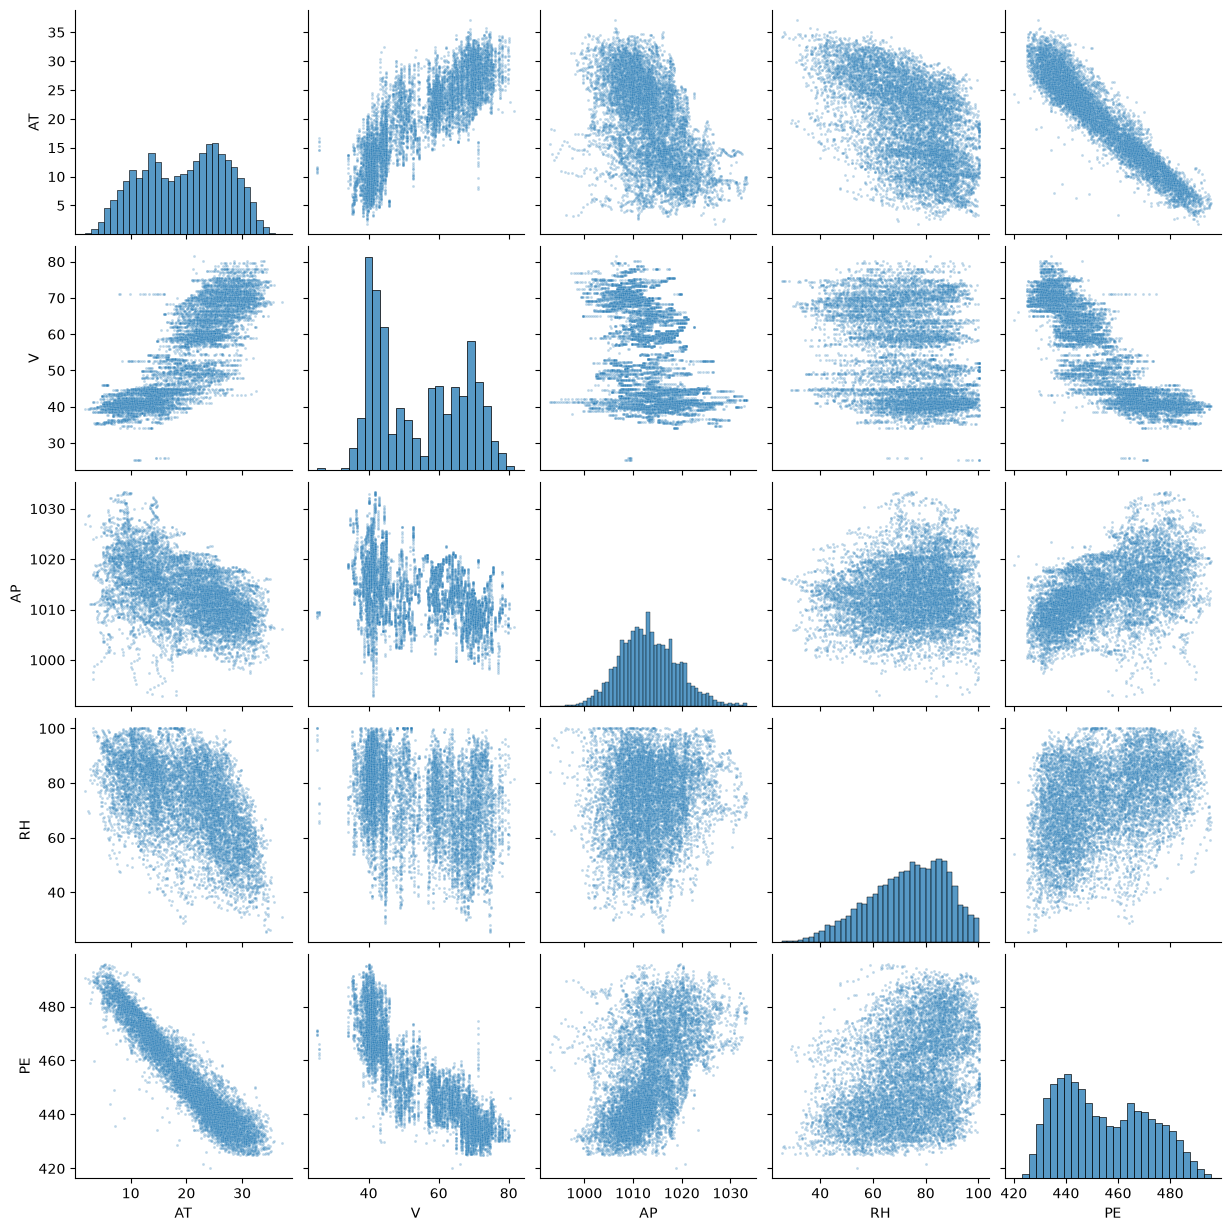

AT is strongly, almost linearly negatively correlated with PE and positively correlated with V. AT and RH are negatively and loosely correlated with pE with wide spread distribution. AT and PE histograms are bimodal which may be caused by seasonaL variation.


In [4]:
#ii) pairwise scatterlots
sns.pairplot(df, plot_kws=dict(s=4, alpha=0.3)); plt.show()
df.corr().round(3)
print("AT is strongly, almost linearly negatively correlated with PE and positively correlated with V. AT and RH are negatively and loosely correlated with pE with wide spread distribution. AT and PE histograms are bimodal which may be caused by seasonaL variation.")

In [5]:
#iii. Summary Statistics
s = pd.DataFrame({'Mean': df.mean(), 'Median': df.median(),
                  'Range': df.max() - df.min(),
                  'Q1': df.quantile(.25), 'Q3': df.quantile(.75)})
s['IQR'] = s.Q3 - s.Q1
s

,Mean,Median,Range,Q1,Q3,IQR
AT,19.651231,20.345,35.30,13.5100,25.72,12.2100
V,54.305804,52.080,56.20,41.7400,66.54,24.8000
AP,1013.259078,1012.940,40.41,1009.1000,1017.26,8.1600
RH,73.308978,74.975,74.60,63.3275,84.83,21.5025
PE,454.365009,451.550,75.50,439.7500,468.43,28.6800


AT: b1=-2.171, t=-291.7, p=0.00e+00, R2=0.899, |r|>3: 42
V: b1=-1.168, t=-172.4, p=0.00e+00, R2=0.757, |r|>3: 33
AP: b1=1.490, t=59.3, p=0.00e+00, R2=0.269, |r|>3: 30
RH: b1=0.456, t=41.4, p=0.00e+00, R2=0.152, |r|>3: 2


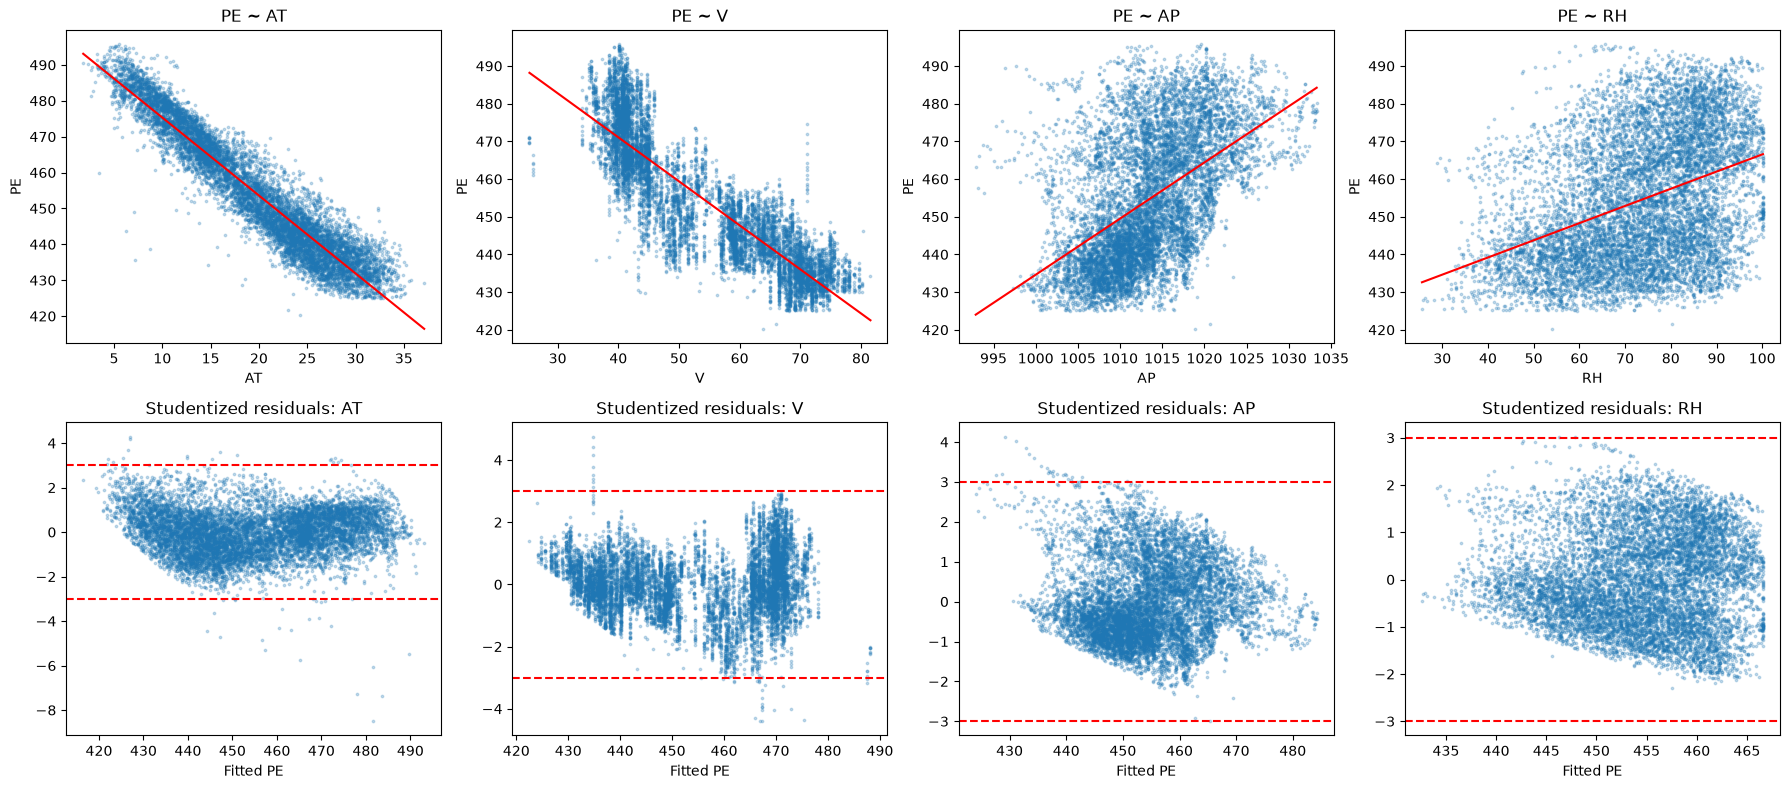

All four predictors have a statistically significant association with PE (p < 0.001). With n = 9,568 this is expected, so the R² values are more informative: AT alone explains about 90% of the variance in PE. V explains about 76%. AP (27%) and RH (15%) leave most of the variance unexplained.The residual plots for AT and V show curvature, suggesting some nonlinearity (examined in part f).
only 42 in AT, 33 in V, 30 in AP,2 in RH data points have studentized residual's absolute value >3, which makes up 0.5% of total sample size. They are likely just legitimate operating hours rather than data errors, and they can be ignored in such big dataset. I will not remove the outliers


In [6]:
#c) For each predictor, fit a simple linear regression model to predict the response.
#Describe your results. In which of the models is there a statistically significant
#association between the predictor and the response? Create some plots to back
#up your assertions. Are there any outliers that you would like to remove from
#your data for each of these regression tasks?

simple = {}
fig, ax = plt.subplots(2, 4, figsize=(18, 8))
for i, x in enumerate(predictors):
    m = smf.ols(f'PE ~ {x}', df).fit(); simple[x] = m
    r = m.get_influence().resid_studentized_external
    print(f"{x}: b1={m.params[x]:.3f}, t={m.tvalues[x]:.1f}, p={m.pvalues[x]:.2e}, "
          f"R2={m.rsquared:.3f}, |r|>3: {(abs(r) > 3).sum()}")
    xs = np.linspace(df[x].min(), df[x].max(), 100)
    ax[0, i].scatter(df[x], df.PE, s=3, alpha=.25)
    ax[0, i].plot(xs, m.params['Intercept'] + m.params[x]*xs, 'r')
    ax[0, i].set(title=f'PE ~ {x}', xlabel=x, ylabel='PE')
    ax[1, i].scatter(m.fittedvalues, r, s=3, alpha=.25)
    ax[1, i].axhline(3, c='r', ls='--'); ax[1, i].axhline(-3, c='r', ls='--')
    ax[1, i].set(title=f'Studentized residuals: {x}', xlabel='Fitted PE')
plt.tight_layout(); plt.show()

print("All four predictors have a statistically significant association with PE (p < 0.001). With n = 9,568 this is expected, so the R² values are more informative: AT alone explains about 90% of the variance in PE. V explains about 76%. AP (27%) and RH (15%) leave most of the variance unexplained.The residual plots for AT and V show curvature, suggesting some nonlinearity (examined in part f).")
print("only 42 in AT, 33 in V, 30 in AP,2 in RH data points have studentized residual's absolute value >3, which makes up 0.5% of total sample size. They are likely just legitimate operating hours rather than data errors, and they can be ignored in such big dataset. I will not remove the outliers")

In [7]:
#d) Multiple Linear Regression

full = smf.ols('PE ~ AT + V + AP + RH', df).fit()
print(full.summary())


                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.929
Model:                            OLS   Adj. R-squared:                  0.929
Method:                 Least Squares   F-statistic:                 3.114e+04
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        17:34:07   Log-Likelihood:                -28088.
No. Observations:                9568   AIC:                         5.619e+04
Df Residuals:                    9563   BIC:                         5.622e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    454.6093      9.749     46.634      0.0

      Simple  Multiple
AT -2.171320 -1.977513
V  -1.168135 -0.233916
AP  1.489872  0.062083
RH  0.455650 -0.158054


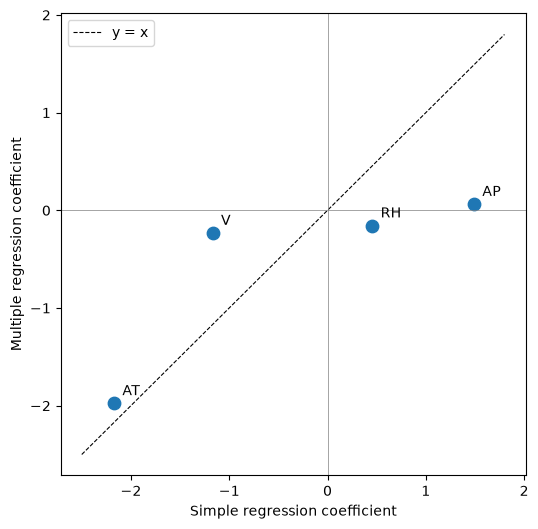

The coefficient of AT is nearly unchanged, because it is the dominant predictor.
The coefficients of V and AP shrink substantially. Both are correlated with AT, so in simple regression they partly capture its effect.
RH changes sign, from positive in simple regression to negative in multiple regression. Humidity is negatively correlated with temperature (r = −0.543), and cooler hours produce more power. The simple regression slope of RH therefore reflects the temperature effect. Once AT is controlled for, the partial effect of humidity is slightly negative.


In [8]:
#e)Simple vs. Multiple Regression Coefficients

cmp = pd.DataFrame({'Simple': [simple[x].params[x] for x in predictors],
                    'Multiple': full.params[predictors].values}, index=predictors)
print(cmp)
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(cmp.Simple, cmp.Multiple, s=80)
for p, r in cmp.iterrows(): ax.annotate(p, (r.Simple, r.Multiple), xytext=(6, 6), textcoords='offset points')
lim = [-2.5, 1.8]; ax.plot(lim, lim, 'k--', lw=.8, label='y = x')
ax.axhline(0, c='grey', lw=.5); ax.axvline(0, c='grey', lw=.5)
ax.set(xlabel='Simple regression coefficient', ylabel='Multiple regression coefficient'); ax.legend()
plt.show()

print("The coefficient of AT is nearly unchanged, because it is the dominant predictor.")
print("The coefficients of V and AP shrink substantially. Both are correlated with AT, so in simple regression they partly capture its effect.")
print("RH changes sign, from positive in simple regression to negative in multiple regression. Humidity is negatively correlated with temperature (r = −0.543), and cooler hours produce more power. The simple regression slope of RH therefore reflects the temperature effect. Once AT is controlled for, the partial effect of humidity is slightly negative.")

In [12]:
#f)
for x in predictors:
    d = pd.DataFrame({'y': df.PE, 'x': df[x] - df[x].mean()})
    m = smf.ols('y ~ x + I(x**2) + I(x**3)', d).fit()
    print(x, m.pvalues.round(4).to_dict(), f"R2={m.rsquared:.4f}")

print("There is evidence of nonlinear association for every predictor: For AT, V and AP, the quadratic term is significant, the cubic term is also significant at α = 0.05. For RH, the cubic term is significant but the quadratic term is not p = 0.101, and R² barely changes.")

AT {'Intercept': 0.0, 'x': 0.0, 'I(x ** 2)': 0.0, 'I(x ** 3)': 0.0} R2=0.9119
V {'Intercept': 0.0, 'x': 0.0, 'I(x ** 2)': 0.0, 'I(x ** 3)': 0.0137} R2=0.7750
AP {'Intercept': 0.0, 'x': 0.0, 'I(x ** 2)': 0.0, 'I(x ** 3)': 0.0} R2=0.2975
RH {'Intercept': 0.0, 'x': 0.0, 'I(x ** 2)': 0.1014, 'I(x ** 3)': 0.0} R2=0.1537
There is evidence of nonlinear association for every predictor: For AT, V and AP, the quadratic term is significant, the cubic term is also significant at α = 0.05. For RH, the cubic term is significant but the quadratic term is not p = 0.101, and R² barely changes.


In [13]:
#g)
inter = smf.ols('PE ~ (AT + V + AP + RH)**2', df).fit()
print(inter.summary())
print("AT:V, AT:RH, V:AP and AP:RH are statistically significant at α = 0.05; AT:AP and V:RH are not. There is therefore evidence that interactions between predictors are associated with the response.The main effect of AT now has p = 0.067. This does not mean temperature is unimportant. Its effect is spread across the interaction terms, which are highly collinear with it. By the hierarchy principle, AT should be retained because its interactions are in the model.")

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.936
Model:                            OLS   Adj. R-squared:                  0.936
Method:                 Least Squares   F-statistic:                 1.405e+04
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        17:37:03   Log-Likelihood:                -27548.
No. Observations:                9568   AIC:                         5.512e+04
Df Residuals:                    9557   BIC:                         5.520e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    685.7825     78.640      8.721      0.0

In [14]:
#h)
train, test = train_test_split(df, test_size=0.3, random_state=SEED)

# Model 1: linear, all predictors
m1 = smf.ols('PE ~ AT + V + AP + RH', train).fit()

# Model 2: all interactions + quadratic terms, backward elimination respecting hierarchy
terms = predictors + [f'{a}:{b}' for a, b in itertools.combinations(predictors, 2)] \
        + [f'I({x}**2)' for x in predictors]
def parents(t):
    if ':' in t: return t.split(':')
    if t.startswith('I('): return [t[2:t.index('*')]]
    return []
removed = []
while True:
    m2 = smf.ols('PE ~ ' + ' + '.join(terms), train).fit()
    pv = m2.pvalues.drop('Intercept'); pv.index = [t.replace(' ** ', '**') for t in pv.index]
    needed = {p for t in terms for p in parents(t)}          # main effects still required
    cand = pv[[t for t in pv.index if t not in needed]]
    if cand.empty or cand.max() < 0.05: break
    worst = cand.idxmax(); removed.append((worst, round(cand.max(), 3))); terms.remove(worst)
print('Removed:', removed); print('Final terms:', terms)

for name, m in [('Linear', m1), ('Interaction + Quadratic', m2)]:
    print(f"{name}: train MSE = {mse(train.PE, m.predict(train)):.2f}, "
          f"test MSE = {mse(test.PE, m.predict(test)):.2f}")

print("The pruned model reduces test MSE from 21.74 to 19.08, about a 12% improvement. Because test MSE decreases along with training MSE, the gain reflects real improvement rather than overfitting. Yes, the model can be improved by including interaction terms and quadratic nonlinearities.")

Removed: [('AT:AP', np.float64(0.492)), ('V:RH', np.float64(0.379)), ('I(V**2)', np.float64(0.093))]
Final terms: ['AT', 'V', 'AP', 'RH', 'AT:V', 'AT:RH', 'V:AP', 'AP:RH', 'I(AT**2)', 'I(AP**2)', 'I(RH**2)']
Linear: train MSE = 20.35, test MSE = 21.74
Interaction + Quadratic: train MSE = 17.71, test MSE = 19.08
The pruned model reduces test MSE from 21.74 to 19.08, about a 12% improvement. Because test MSE decreases along with training MSE, the gain reflects real improvement rather than overfitting. Yes, the model can be improved by including interaction terms and quadratic nonlinearities.


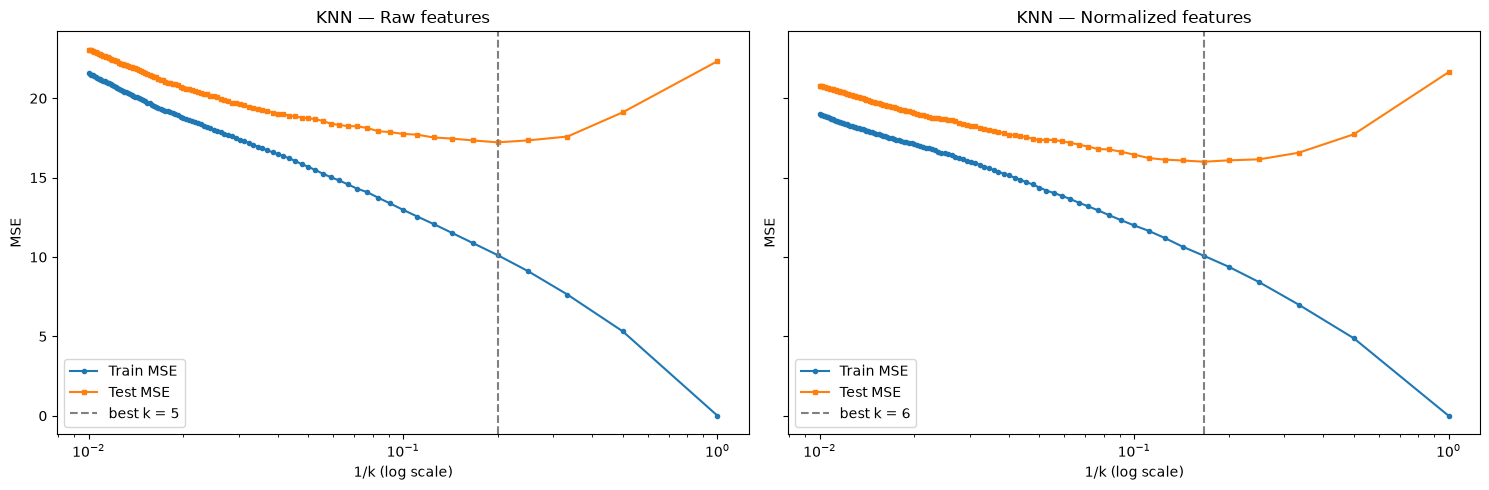

{'Raw': (np.int64(5), 10.117292645064952, 17.222491062347604), 'Normalized': (np.int64(6), 10.077763205747184, 16.00172432272921)}
The best fit is k = 5 with raw features test MSE = 17.22 and k = 6 with normalized features (test MSE = 16.00). In the plots, training error is 0 at k = 1 or 1/k = 1, because each training point is its own nearest neighbor. Training error increases as k grows, moving left. Test error follows a U-shape: it is high for very small k ,high variance and overfitting;it reaches its minimum at the best k;it rises again for large k high bias and underfitting. Normalized features give lower test error. With raw features, the distance metric is dominated by variables with large numeric ranges, e.g. RH, V) which under-weights AT, the most informative predictor.


In [18]:
#i)
Xtr, Xte = train[predictors].values, test[predictors].values
ytr, yte = train.PE.values, test.PE.values
sc = StandardScaler().fit(Xtr)                                  # fit on training data only
sets = {'Raw': (Xtr, Xte), 'Normalized': (sc.transform(Xtr), sc.transform(Xte))}
ks = np.arange(1, 101); best = {}

fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)
for ax, (name, (A, B)) in zip(axes, sets.items()):
    tr, te = [], []
    for k in ks:
        knn = KNeighborsRegressor(n_neighbors=k).fit(A, ytr)
        tr.append(mse(ytr, knn.predict(A))); te.append(mse(yte, knn.predict(B)))
    i = int(np.argmin(te)); best[name] = (ks[i], tr[i], te[i])
    ax.plot(1/ks, tr, 'o-', ms=3, label='Train MSE')
    ax.plot(1/ks, te, 's-', ms=3, label='Test MSE')
    ax.axvline(1/ks[i], c='grey', ls='--', label=f'best k = {ks[i]}')
    ax.set(xscale='log', xlabel='1/k (log scale)', ylabel='MSE', title=f'KNN — {name} features'); ax.legend()
plt.tight_layout(); plt.show()
print(best)
print("The best fit is k = 5 with raw features test MSE = 17.22 and k = 6 with normalized features (test MSE = 16.00). In the plots, training error is 0 at k = 1 or 1/k = 1, because each training point is its own nearest neighbor. Training error increases as k grows, moving left. Test error follows a U-shape: it is high for very small k ,high variance and overfitting;it reaches its minimum at the best k;it rises again for large k high bias and underfitting. Normalized features give lower test error. With raw features, the distance metric is dominated by variables with large numeric ranges, e.g. RH, V) which under-weights AT, the most informative predictor.")

In [20]:
#j)
print("The normalized KNN model achieves the lowest test MSE (16.00), about 16% lower than the best linear regression model (19.08) KNN predict better here because There are only four predictors and roughly 6,700 training observations, so every test point has many close neighbors. KNN can capture the nonlinearities and interactions in the data directly, without us having to specify the functional form. The linear model captures only the terms we explicitly include.If the goal is purely predictive accuracy, normalized KNN is preferred. If understanding what drives the plant's energy output matters, the regression model with interaction and quadratic terms is the better choice.")

The normalized KNN model achieves the lowest test MSE (16.00), about 16% lower than the best linear regression model (19.08) KNN predict better here because There are only four predictors and roughly 6,700 training observations, so every test point has many close neighbors. KNN can capture the nonlinearities and interactions in the data directly, without us having to specify the functional form. The linear model captures only the terms we explicitly include.If the goal is purely predictive accuracy, normalized KNN is preferred. If understanding what drives the plant's energy output matters, the regression model with interaction and quadratic terms is the better choice.


In [22]:
#2
import textwrap

print("=" * 70)
print("Q2 (ISLR 2.4.1): Flexible vs. Inflexible Statistical Learning Methods")
print("=" * 70)

q2_answers = {
    "(a) Sample size n is extremely large, number of predictors p is small.": (
        "Better",
        "With a very large n and few predictors, there is enough data to estimate a "
        "flexible model reliably, so its variance stays low. The flexible method can then "
        "take advantage of its lower bias and capture the true shape of f more accurately "
        "than an inflexible method."
    ),
    "(b) Number of predictors p is extremely large, n is small.": (
        "Worse",
        "With many predictors and few observations, a flexible method has too many degrees "
        "of freedom relative to the data. It will overfit the training set, fitting noise "
        "rather than signal, which leads to high variance and poor test performance. An "
        "inflexible method is more robust here. Flexible methods such as KNN also suffer "
        "from the curse of dimensionality when p is large."
    ),
    "(c) The relationship between the predictors and response is highly non-linear.": (
        "Better",
        "An inflexible method such as linear regression cannot represent a highly non-linear "
        "f, so it would have large bias. A flexible method can adapt to the non-linear shape, "
        "substantially reducing bias."
    ),
    "(d) The variance of the error terms, sigma^2 = Var(epsilon), is extremely high.": (
        "Worse",
        "When the irreducible error is very large, the data contain a lot of noise. A flexible "
        "method will tend to fit that noise (high variance), producing an unstable fit that "
        "generalizes poorly. An inflexible method averages over the noise and gives a more "
        "stable estimate."
    ),
}

for question, (verdict, reason) in q2_answers.items():
    print(f"\n{question}")
    print(f"  Answer: {verdict}")
    print(textwrap.indent(textwrap.fill(f"Reason: {reason}", width=85), "  "))

Q2 (ISLR 2.4.1): Flexible vs. Inflexible Statistical Learning Methods

(a) Sample size n is extremely large, number of predictors p is small.
  Answer: Better
  Reason: With a very large n and few predictors, there is enough data to estimate a
  flexible model reliably, so its variance stays low. The flexible method can then take
  advantage of its lower bias and capture the true shape of f more accurately than an
  inflexible method.

(b) Number of predictors p is extremely large, n is small.
  Answer: Worse
  Reason: With many predictors and few observations, a flexible method has too many
  degrees of freedom relative to the data. It will overfit the training set, fitting
  noise rather than signal, which leads to high variance and poor test performance. An
  inflexible method is more robust here. Flexible methods such as KNN also suffer from
  the curse of dimensionality when p is large.

(c) The relationship between the predictors and response is highly non-linear.
  Answer: Bette

In [25]:
#3
import textwrap
import numpy as np
import pandas as pd

print("=" * 70)
print("Q3 (ISLR 2.4.7): K-Nearest Neighbors Classification")
print("=" * 70)

data = pd.DataFrame({
    "Obs": [1, 2, 3, 4, 5, 6],
    "X1":  [0, 2, 0, 0, -1, 1],
    "X2":  [3, 0, 1, 1, 0, 1],
    "X3":  [0, 0, 3, 2, 1, 1],
    "Y":   ["Red", "Red", "Red", "Green", "Green", "Red"],
}).set_index("Obs")
test_point = np.array([0, 0, 0])

print("\nTraining data:")
print(data)

# (a) Euclidean distances
print("\n(a) Euclidean distance from each observation to the test point (0, 0, 0)")
data["Distance"] = np.sqrt(((data[["X1", "X2", "X3"]].values - test_point) ** 2).sum(axis=1))
sq = lambda v: f"({v})^2" if v < 0 else f"{v}^2"
for obs, row in data.iterrows():
    total = int(row.X1**2 + row.X2**2 + row.X3**2)
    print(f"  Obs {obs}: sqrt({sq(row.X1)} + {sq(row.X2)} + {sq(row.X3)}) "
          f"= sqrt({total}) = {row.Distance:.3f}  ({row.Y})")

ranked = data.sort_values("Distance")
print("\n  Observations ordered by distance:")
print(ranked[["Distance", "Y"]].round(3))

# (b) and (c) KNN predictions
def knn_predict(K):
    neighbors = ranked.head(K)
    votes = neighbors["Y"].value_counts()
    return neighbors, votes, votes.idxmax()

for part, K in [("(b)", 1), ("(c)", 3)]:
    neighbors, votes, pred = knn_predict(K)
    print(f"\n{part} Prediction with K = {K}: {pred}")
    print(f"  Nearest {K} neighbor(s): " +
          ", ".join(f"Obs {o} ({r.Y}, d={r.Distance:.3f})" for o, r in neighbors.iterrows()))
    print("  Estimated class probabilities: " +
          ", ".join(f"P({c}) = {n}/{K}" for c, n in votes.items()))
    if K == 1:
        print("  Reason: With K = 1 the prediction is the class of the single nearest "
              "neighbor, Obs 5, which is Green.")
    else:
        print("  Reason: Two of the three nearest neighbors are Red, so the majority "
              "vote predicts Red.")

# (d)
print("\n(d) If the Bayes decision boundary is highly non-linear, should K be large or small?")
print("  Answer: Small")
print(textwrap.indent(textwrap.fill(
    "Reason: A small K produces a highly flexible classifier whose decision boundary can "
    "bend to follow local structure in the data, which is needed to approximate a highly "
    "non-linear Bayes decision boundary. As K increases, KNN averages over more neighbors "
    "and the boundary becomes smoother and closer to linear, which would introduce large "
    "bias. K should not be too small either (K = 1 may overfit), but in general a highly "
    "non-linear boundary favors a smaller K.", width=85), "  "))

Q3 (ISLR 2.4.7): K-Nearest Neighbors Classification

Training data:
     X1  X2  X3      Y
Obs                   
1     0   3   0    Red
2     2   0   0    Red
3     0   1   3    Red
4     0   1   2  Green
5    -1   0   1  Green
6     1   1   1    Red

(a) Euclidean distance from each observation to the test point (0, 0, 0)
  Obs 1: sqrt(0^2 + 3^2 + 0^2) = sqrt(9) = 3.000  (Red)
  Obs 2: sqrt(2^2 + 0^2 + 0^2) = sqrt(4) = 2.000  (Red)
  Obs 3: sqrt(0^2 + 1^2 + 3^2) = sqrt(10) = 3.162  (Red)
  Obs 4: sqrt(0^2 + 1^2 + 2^2) = sqrt(5) = 2.236  (Green)
  Obs 5: sqrt((-1)^2 + 0^2 + 1^2) = sqrt(2) = 1.414  (Green)
  Obs 6: sqrt(1^2 + 1^2 + 1^2) = sqrt(3) = 1.732  (Red)

  Observations ordered by distance:
     Distance      Y
Obs                 
5       1.414  Green
6       1.732    Red
2       2.000    Red
4       2.236  Green
1       3.000    Red
3       3.162    Red

(b) Prediction with K = 1: Green
  Nearest 1 neighbor(s): Obs 5 (Green, d=1.414)
  Estimated class probabilities: P(Green) =